<a href="https://colab.research.google.com/github/Joseph-raji6/titanic-survival-analysis/blob/main/Titanic_colab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUCTION
 The goal of this project is to perform Exploratory Data Analysis (EDA) on the  Titanic3 dataset, which contains information about the survival of passengers during the Titanic disaster and is based on passenger  characteristics and socio-economic variables. The data was collected from historical and social research and contains information such as  age, gender, passenger class and survival.

This study will attempt to summarize the data through descriptive  statistics, visualize the variables and their relationships using charts and plots, identify the target variable (Survived)  and its key predictors. Classification tree models will also be applied to see which factors are most related to  survival.

In this study, Python (Pandas, Matplotlib, Seaborn) and R  will be used in a Google Colab environment to identify patterns in the data and present the findings in  a simple and easy to understand format.

# Importing Libraries
 When performing EDA of the Titanic3 dataset, it is crucial to import libraries like  Pandas, Matplotlib, Seaborn, and Tidyverse (for R). Pandas makes data  manipulation easy, and Matplotlib and Seaborn are tools for visualization to help find patterns.  Also, Tidyverse and dplyr (in R) are useful for data cleaning and transformation.  These libraries are very useful in analysis and make it easier to explore and interpret the dataset clearly.

In [ ]:
#initialise R
%load_ext rpy2.ipython

In [ ]:
# activate R magic
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
#install.packages("tidyverse")
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
%%R
install.packages("PASWR")
library(PASWR)

(as ‘lib’ is unspecified)



















	‘/tmp/Rtmp4PkgUb/downloaded_packages’




In [ ]:
%%R
#own
write.csv(titanic3,"titanic3.csv")

In [ ]:
#https://www.kaggle.com/abhishekmaamidi/titanic-data-processing-and-visualization/notebook?select=train.csv
#Python library
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
#Data
titanic3 = pd.read_csv("titanic3.csv")

In [ ]:
%%R
glimpse(titanic3)

Rows: 1,309
Columns: 14
$ pclass    <fct> 1st, 1st, 1st, 1st, 1st, 1st, 1st, 1st, 1st, 1st, 1st, 1st, …
$ survived  <int> 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, …
$ name      <fct> "Allen, Miss. Elisabeth Walton", "Allison, Master. Hudson Tr…
$ sex       <fct> female, male, female, male, female, male, female, male, fema…
$ age       <dbl> 29.0000, 0.9167, 2.0000, 30.0000, 25.0000, 48.0000, 63.0000,…
$ sibsp     <int> 0, 1, 1, 1, 1, 0, 1, 0, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, …
$ parch     <int> 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, …
$ ticket    <fct> 24160, 113781, 113781, 113781, 113781, 19952, 13502, 112050,…
$ fare      <dbl> 211.3375, 151.5500, 151.5500, 151.5500, 151.5500, 26.5500, 7…
$ cabin     <fct> B5, C22 C26, C22 C26, C22 C26, C22 C26, E12, D7, A36, C101, …
$ embarked  <fct> Southampton, Southampton, Southampton, Southampton, Southamp…
$ boat      <fct> 2, 11, , , , 3, 10, , D, , , 4, 9, 6, B, , , 6, 8, A, 5, 5, …
$ body      <int

In [ ]:
# dplyr
%%R
titanic3 %>% group_by(survived) %>% count()

# A tibble: 2 × 2
# Groups:   survived [2]
  survived     n
     <int> <int>
1        0   809
2        1   500


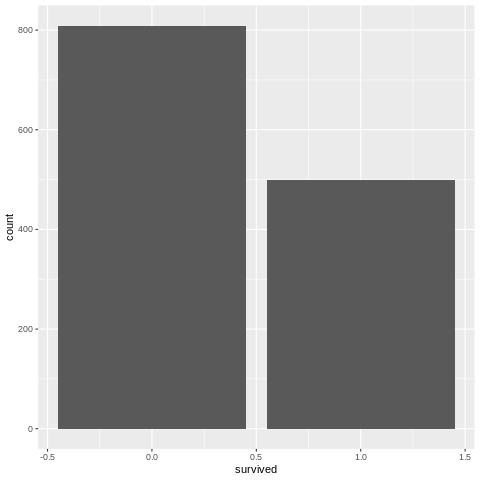

In [ ]:
%%R
# ggplot2
ggplot(titanic3, aes(x = survived)) +
  geom_bar()

# The Data
 Using various data manipulation and visualization techniques, we attempt to uncover relationships between variables and, through  this, to summarize important characteristics. In this section, we approach the Titanic3 dataset to examine its structure  and find important patterns. This analysis will provide a deeper understanding of the dataset and will prepare the way  for further modeling and interpretation.

# Survival rate of passengers in relation to those that drowned

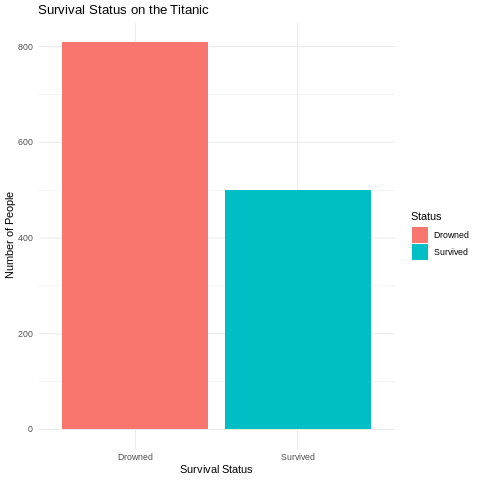

In [ ]:
%%R

# Load the Titanic dataset
data("titanic3")

# Create a summary table for survival
survival_data <- titanic3 %>%
  mutate(survived = ifelse(survived == 1, "Survived", "Drowned")) %>%
  count(survived)

# Plot the bar chart
ggplot(survival_data, aes(x = survived, y = n, fill = survived)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Survival Status on the Titanic",
    x = "Survival Status",
    y = "Number of People",
    fill = "Status"
  ) +
  theme_minimal()


From this we can see that a larger proportion of people who boarded the titanic drowend than those who survived

Target variable: Sex

# Survival rates broken down between males and females

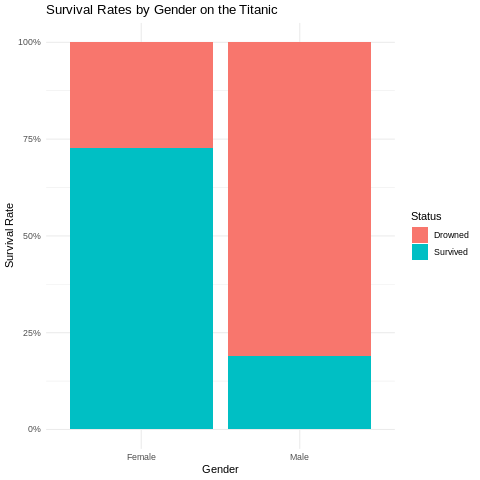

In [ ]:
%%R

# Load the Titanic dataset
data("titanic3")

# Calculate survival rates by gender
gender_survival <- titanic3 %>%
  mutate(
    survived = ifelse(survived == 1, "Survived", "Drowned"),
    gender = ifelse(sex == "male", "Male", "Female")
  ) %>%
  group_by(gender, survived) %>%
  summarize(count = n(), .groups = "drop") %>%
  group_by(gender) %>%
  mutate(rate = count / sum(count))

# Plot the survival rates by gender
ggplot(gender_survival, aes(x = gender, y = rate, fill = survived)) +
  geom_bar(stat = "identity", position = "fill") +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Survival Rates by Gender on the Titanic",
    x = "Gender",
    y = "Survival Rate",
    fill = "Status"
  ) +
  theme_minimal()


In terms of male and female surviavl rates we can deduce that more males died in comparison to females.This shows us that females were given priority over men in the survival process.

# Target variable: Class

# Survival rates broken down by class

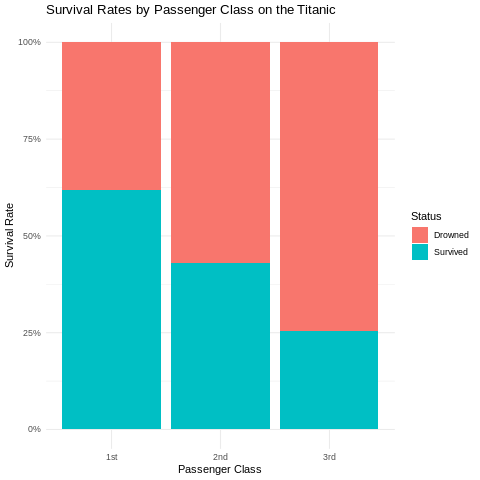

In [ ]:
%%R

# Load the Titanic dataset
data("titanic3")

# Calculate survival rates by passenger class
class_survival <- titanic3 %>%
  mutate(
    survived = ifelse(survived == 1, "Survived", "Drowned")
  ) %>%
  group_by(pclass, survived) %>%
  summarize(count = n(), .groups = "drop") %>%
  group_by(pclass) %>%
  mutate(rate = count / sum(count))

# Plot the survival rates by class
ggplot(class_survival, aes(x = as.factor(pclass), y = rate, fill = survived)) +
  geom_bar(stat = "identity", position = "fill") +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Survival Rates by Passenger Class on the Titanic",
    x = "Passenger Class",
    y = "Survival Rate",
    fill = "Status"
  ) +
  theme_minimal()


This graphic shows us that the percentages of survivors decreases by class. This tells us that those in a higher class also had priority in the survival process

# The survival rate by class of ticket and sex

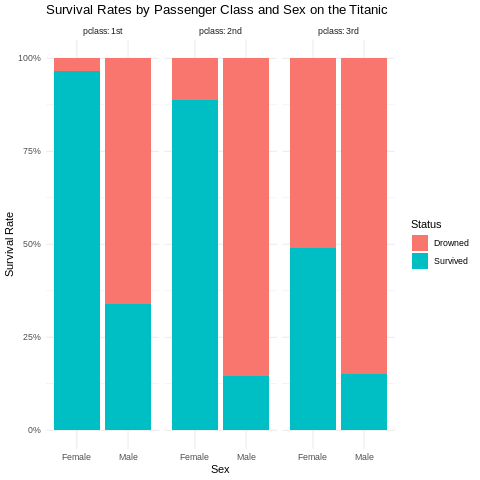

In [ ]:
%%R

# Load the Titanic dataset
data("titanic3")

# Calculate survival rates by class and sex
class_sex_survival <- titanic3 %>%
  mutate(
    survived = ifelse(survived == 1, "Survived", "Drowned"),
    sex = ifelse(sex == "male", "Male", "Female"),
    pclass = as.factor(pclass)  # Ensure pclass is treated as categorical
  ) %>%
  group_by(pclass, sex, survived) %>%
  summarize(count = n(), .groups = "drop") %>%
  group_by(pclass, sex) %>%
  mutate(rate = count / sum(count))

# Plot the survival rates by class and sex
ggplot(class_sex_survival, aes(x = sex, y = rate, fill = survived)) +
  geom_bar(stat = "identity", position = "fill") +
  facet_wrap(~pclass, labeller = label_both) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(
    title = "Survival Rates by Passenger Class and Sex on the Titanic",
    x = "Sex",
    y = "Survival Rate",
    fill = "Status"
  ) +
  theme_minimal()


# Target Variable: Age

# Distribution of passengers ages

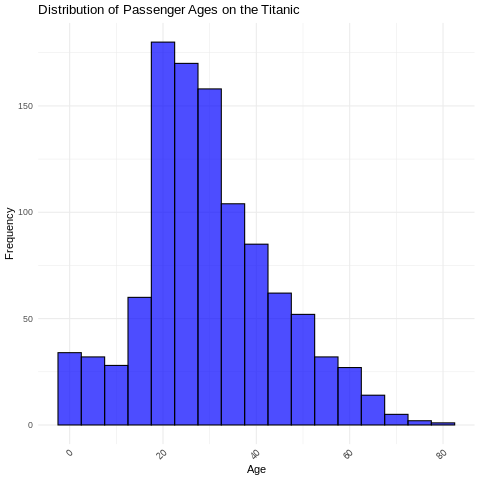

In [ ]:
%%R

# Load the Titanic dataset
data("titanic3")

# Plot the distribution of passenger ages
ggplot(titanic3, aes(x = age)) +
  geom_histogram(binwidth = 5, fill = "blue", color = "black", alpha = 0.7) +
  labs(
    title = "Distribution of Passenger Ages on the Titanic",
    x = "Age",
    y = "Frequency"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)  # Rotate x-axis labels for better readability
  )


# Survival Distribution by age

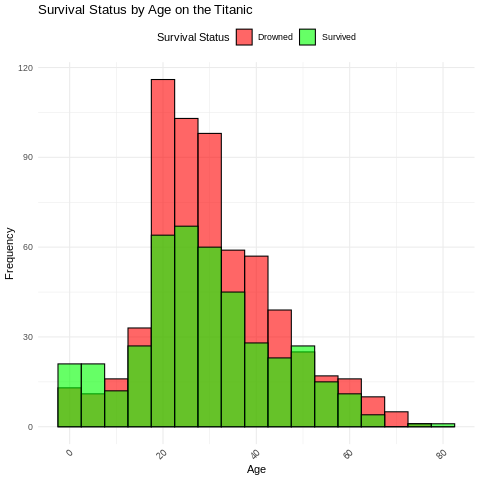

In [ ]:
%%R

# Load the Titanic dataset
data("titanic3")

# Plot the survival status by age
ggplot(titanic3, aes(x = age, fill = factor(survived))) +
  geom_histogram(binwidth = 5, position = "identity", alpha = 0.6, color = "black") +
  scale_fill_manual(values = c("red", "green"), labels = c("Drowned", "Survived")) +
  labs(
    title = "Survival Status by Age on the Titanic",
    x = "Age",
    y = "Frequency",
    fill = "Survival Status"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for better readability
    legend.position = "top"  # Position legend at the top
  )


# Distribution of passengers by age,class and there survival rate

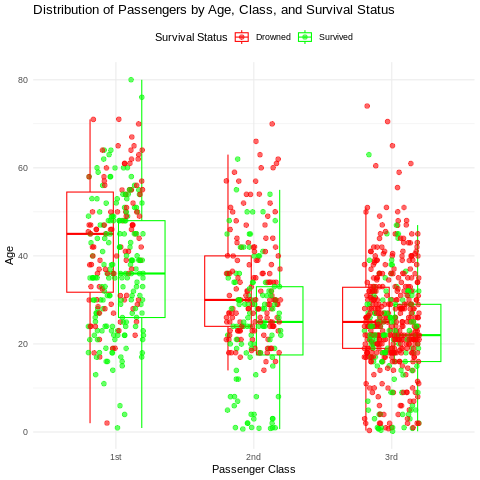

In [ ]:
%%R

# Load the Titanic dataset
data("titanic3")

# Prepare the data
titanic_data <- titanic3 %>%
  mutate(
    survived = ifelse(survived == 1, "Survived", "Drowned"),
    pclass = as.factor(pclass)  # Treat pclass as a categorical variable
  )

# Plot the boxplot and scatter graph
ggplot(titanic_data, aes(x = pclass, y = age, color = survived)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.5) +  # Boxplot without outliers
  geom_jitter(alpha = 0.6, size = 2, width = 0.2) +  # Scatter plot with jitter
  scale_color_manual(values = c("red", "green")) +
  labs(
    title = "Distribution of Passengers by Age, Class, and Survival Status",
    x = "Passenger Class",
    y = "Age",
    color = "Survival Status"
  ) +
  theme_minimal() +
  theme(
    legend.position = "top"
  )


# The mean and median age of survivors based on class and gender


In [ ]:
%%R

# Load the Titanic dataset
data("titanic3")

# Calculate mean and median age of survivors by class and gender
survivor_age_stats <- titanic3 %>%
  filter(survived == 1) %>%  # Filter only survivors
  mutate(sex = ifelse(sex == "male", "Male", "Female"),
         pclass = as.factor(pclass)) %>%  # Ensure class is categorical
  group_by(pclass, sex) %>%  # Group by class and gender
  summarize(
    mean_age = mean(age, na.rm = TRUE),  # Calculate mean age
    median_age = median(age, na.rm = TRUE),  # Calculate median age
    .groups = "drop"
  )

# Print the result
print(survivor_age_stats)


# A tibble: 6 × 4
  pclass sex    mean_age median_age
  <fct>  <chr>     <dbl>      <dbl>
1 1st    Female     37.1       35.5
2 1st    Male       36.2       36  
3 2nd    Female     26.7       27.5
4 2nd    Male       17.4       19  
5 3rd    Female     20.8       22  
6 3rd    Male       22.4       25  


# The data in columns

In [ ]:
titanic3.head()

,Unnamed: 0,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1st,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.337494,B5,Southampton,2,NaN,"St Louis, MO"
1,2,1st,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.550003,C22 C26,Southampton,11,NaN,"Montreal, PQ / Chesterville, ON"
2,3,1st,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,4,1st,0,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,5,1st,0,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON"


Describing data

In [ ]:
titanic3.describe()

,Unnamed: 0,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,655.000000,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,378.020061,0.486055,14.413500,1.041658,0.865560,51.758669,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,328.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,655.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,982.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,1309.000000,1.000000,80.000000,8.000000,9.000000,512.329224,328.000000


In [ ]:
titanic3.columns

Index(['Unnamed: 0', 'pclass', 'survived', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body',
       'home.dest'],
      dtype='object')

In [ ]:
titanic3.dtypes

,0
Unnamed: 0,int64
pclass,object
survived,int64
name,object
sex,object
age,float64
sibsp,int64
parch,int64
ticket,object
fare,float64


In [ ]:
column_names = titanic3.columns
for column in column_names:
  print(column +' -'+ str(titanic3[column].isnull().sum()))

Unnamed: 0 -0
pclass -0
survived -0
name -0
sex -0
age -263
sibsp -0
parch -0
ticket -0
fare -1
cabin -1014
embarked -2
boat -823
body -1188
home.dest -564


Survivor count shown in a table

In [ ]:
titanic3.survived.value_counts()

,count
survived,
0,809
1,500


# Running the correlation matrix

In coding, a correlation matrix is a table that shows the correlation coefficients between multiple variables. The matrix is a simple cream box with numbers (betweem -1 and 1) that represents the relationship between 2 given variables, with (1) being perfect positive, (-1) perfect negative and (0) no relation. Commonly employed in data analysis and machine learning, it allows understanding relationships between variables

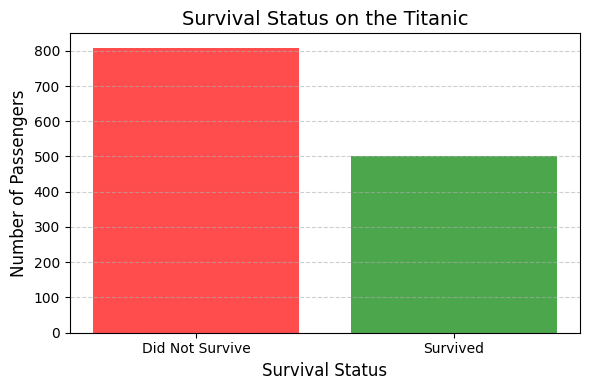

In [ ]:

survival_counts = titanic3['survived'].value_counts()
labels = ['Did Not Survive', 'Survived']
counts = [survival_counts[0], survival_counts[1]]
plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['red', 'green'], alpha=0.7)
plt.title('Survival Status on the Titanic', fontsize=14)
plt.xlabel('Survival Status', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


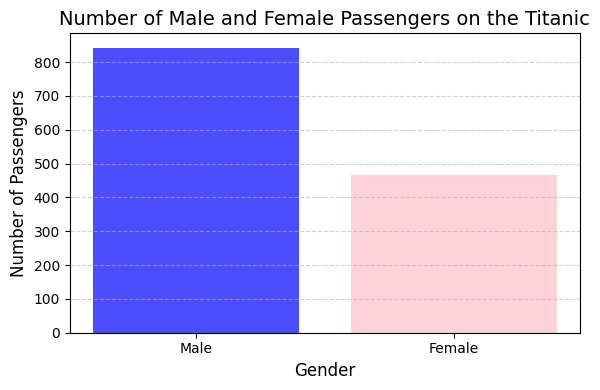

In [ ]:

gender_counts = titanic3['sex'].value_counts()
labels = ['Male', 'Female']
counts = [gender_counts['male'], gender_counts['female']]
plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['blue', 'pink'], alpha=0.7)
plt.title('Number of Male and Female Passengers on the Titanic', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Portraying Families in graphs

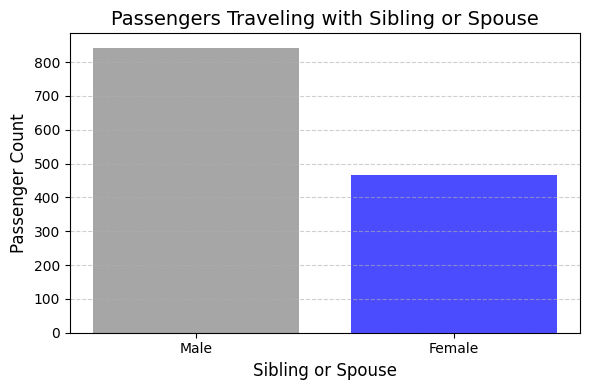

In [ ]:

plt.figure(figsize=(6, 4))  # Compact figure size
plt.bar(labels, counts, color=['gray', 'blue'], alpha=0.7)
plt.title('Passengers Traveling with Sibling or Spouse', fontsize=14)
plt.xlabel('Sibling or Spouse', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


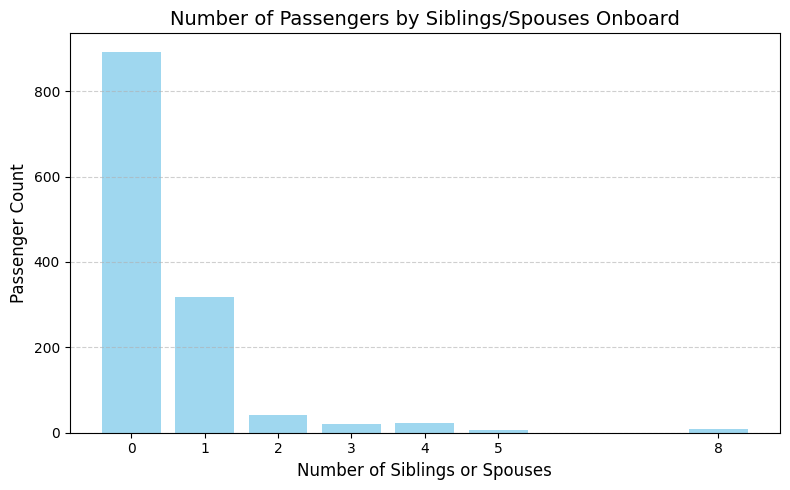

In [ ]:

sibsp_counts = titanic3['sibsp'].value_counts().sort_index()  # Count and sort by the number of siblings/spouses
plt.figure(figsize=(8, 5))  # Adjusted figure size
plt.bar(sibsp_counts.index, sibsp_counts.values, color='skyblue', alpha=0.8)
plt.title('Number of Passengers by Siblings/Spouses Onboard', fontsize=14)
plt.xlabel('Number of Siblings or Spouses', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.xticks(sibsp_counts.index, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


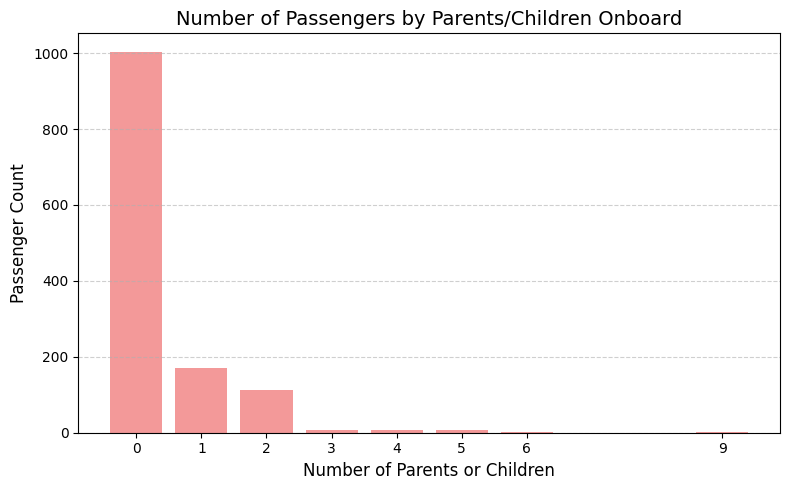

In [ ]:

parch_counts = titanic3['parch'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(parch_counts.index, parch_counts.values, color='lightcoral', alpha=0.8)
plt.title('Number of Passengers by Parents/Children Onboard', fontsize=14)
plt.xlabel('Number of Parents or Children', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.xticks(parch_counts.index, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Location of embark

<ipython-input-32-90ccfdb15496>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


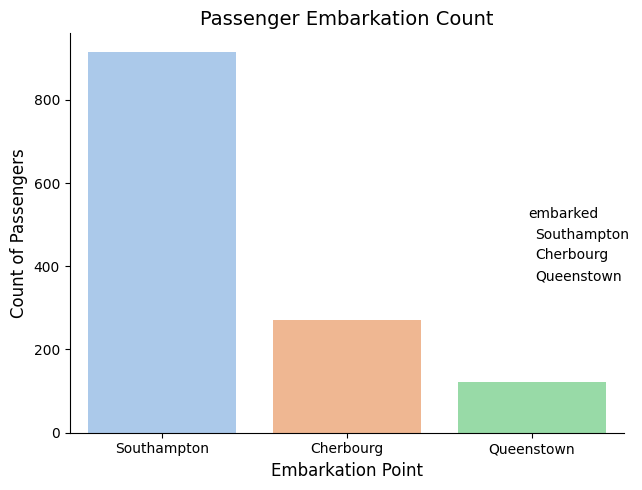

In [ ]:

sns.catplot(
    x="embarked",
    kind="count",
    data=titanic3,
    palette="pastel"
)

# Add title and labels
plt.title('Passenger Embarkation Count', fontsize=14)
plt.xlabel('Embarkation Point', fontsize=12)
plt.ylabel('Count of Passengers', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()


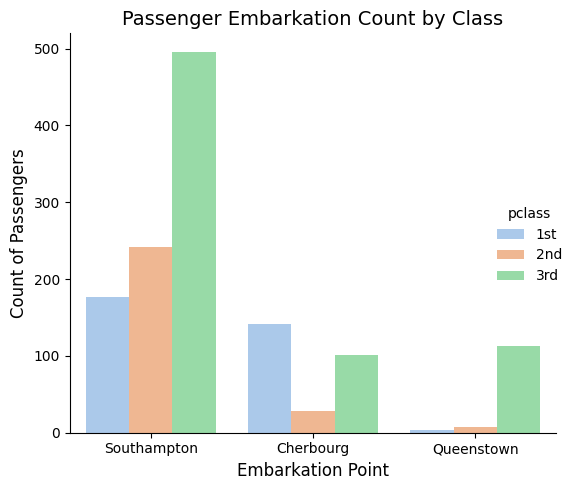

In [ ]:

sns.catplot(
    x="embarked",
    hue="pclass",  # Use 'Pclass' to separate by class
    kind="count",
    data=titanic3,
    palette="pastel"
)

# Add title and labels
plt.title('Passenger Embarkation Count by Class', fontsize=14)
plt.xlabel('Embarkation Point', fontsize=12)
plt.ylabel('Count of Passengers', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()


Portraying sibling, parent and child as 'familysize'

In [ ]:
titanic3['familysize'] = titanic3['sibsp'] + titanic3['parch'] + 1

In [ ]:
titanic3.head()

,Unnamed: 0,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,familysize
0,1,1st,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.337494,B5,Southampton,2,NaN,"St Louis, MO",1
1,2,1st,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.550003,C22 C26,Southampton,11,NaN,"Montreal, PQ / Chesterville, ON",4
2,3,1st,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON",4
3,4,1st,0,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,135.0,"Montreal, PQ / Chesterville, ON",4
4,5,1st,0,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,113781,151.550003,C22 C26,Southampton,NaN,NaN,"Montreal, PQ / Chesterville, ON",4


# Cleaning up columns:
Some of the data and information given in the data set is irreleavnt to the correlation matrix as it gives no insight into survival of the passengers such as 'ticket', 'cabin', 'body' and 'boat'.

In [ ]:
titanic5 = titanic3.drop(columns=['ticket', 'cabin', 'body', 'boat'])


In [ ]:
titanic5.head()

,Unnamed: 0,pclass,survived,name,sex,age,sibsp,parch,fare,embarked,home.dest,familysize
0,1,1st,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,211.337494,Southampton,"St Louis, MO",1
1,2,1st,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,151.550003,Southampton,"Montreal, PQ / Chesterville, ON",4
2,3,1st,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,151.550003,Southampton,"Montreal, PQ / Chesterville, ON",4
3,4,1st,0,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,151.550003,Southampton,"Montreal, PQ / Chesterville, ON",4
4,5,1st,0,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,151.550003,Southampton,"Montreal, PQ / Chesterville, ON",4


In [ ]:
titanic5.drop(titanic5.columns[0], axis=1, inplace=True)


In [ ]:
titanic5.head()

,pclass,survived,name,sex,age,sibsp,parch,fare,embarked,home.dest,familysize
0,1st,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,211.337494,Southampton,"St Louis, MO",1
1,1st,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,151.550003,Southampton,"Montreal, PQ / Chesterville, ON",4
2,1st,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,151.550003,Southampton,"Montreal, PQ / Chesterville, ON",4
3,1st,0,"Allison, Mr. Hudson Joshua Crei",male,30.0000,1,2,151.550003,Southampton,"Montreal, PQ / Chesterville, ON",4
4,1st,0,"Allison, Mrs. Hudson J C (Bessi",female,25.0000,1,2,151.550003,Southampton,"Montreal, PQ / Chesterville, ON",4


# Changing categorcal data:
Changing important categorical data to numerical data is important as it makes it usable in our correlation matrix giving it numerical value

In [ ]:
# Convert 'sex' column: male -> 0, female -> 1
titanic5['sex'] = titanic5['sex'].map({'male': 0, 'female': 1})

# Convert 'embarked' column: Cherbourg -> 0, Queenstown -> 1, Southampton -> 2
titanic5['embarked'] = titanic5['embarked'].map({'Cherbourg': 0, 'Queenstown': 1, 'Southampton': 2})


In [ ]:
titanic5.head()

,pclass,survived,name,sex,age,sibsp,parch,fare,embarked,home.dest,familysize
0,1st,1,"Allen, Miss. Elisabeth Walton",1,29.0000,0,0,211.337494,2.0,"St Louis, MO",1
1,1st,1,"Allison, Master. Hudson Trevor",0,0.9167,1,2,151.550003,2.0,"Montreal, PQ / Chesterville, ON",4
2,1st,0,"Allison, Miss. Helen Loraine",1,2.0000,1,2,151.550003,2.0,"Montreal, PQ / Chesterville, ON",4
3,1st,0,"Allison, Mr. Hudson Joshua Crei",0,30.0000,1,2,151.550003,2.0,"Montreal, PQ / Chesterville, ON",4
4,1st,0,"Allison, Mrs. Hudson J C (Bessi",1,25.0000,1,2,151.550003,2.0,"Montreal, PQ / Chesterville, ON",4


Running matrix again

In [ ]:

numeric_columns = titanic5.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_columns.corr()
correlation_matrix


,survived,sex,age,sibsp,parch,fare,embarked,familysize
survived,1.000000,0.528693,-0.055513,-0.027825,0.082660,0.244265,-0.176796,0.026876
sex,0.528693,1.000000,-0.063646,0.109609,0.213125,0.185523,-0.099408,0.188583
age,-0.055513,-0.063646,1.000000,-0.243699,-0.150917,0.178739,-0.081927,-0.240230
sibsp,-0.027825,0.109609,-0.243699,1.000000,0.373587,0.160238,0.066055,0.861952
parch,0.082660,0.213125,-0.150917,0.373587,1.000000,0.221539,0.045216,0.792296
fare,0.244265,0.185523,0.178739,0.160238,0.221539,1.000000,-0.239086,0.226492
embarked,-0.176796,-0.099408,-0.081927,0.066055,0.045216,-0.239086,1.000000,0.068166
familysize,0.026876,0.188583,-0.240230,0.861952,0.792296,0.226492,0.068166,1.000000


Displaying correlation matrix as a heatmap

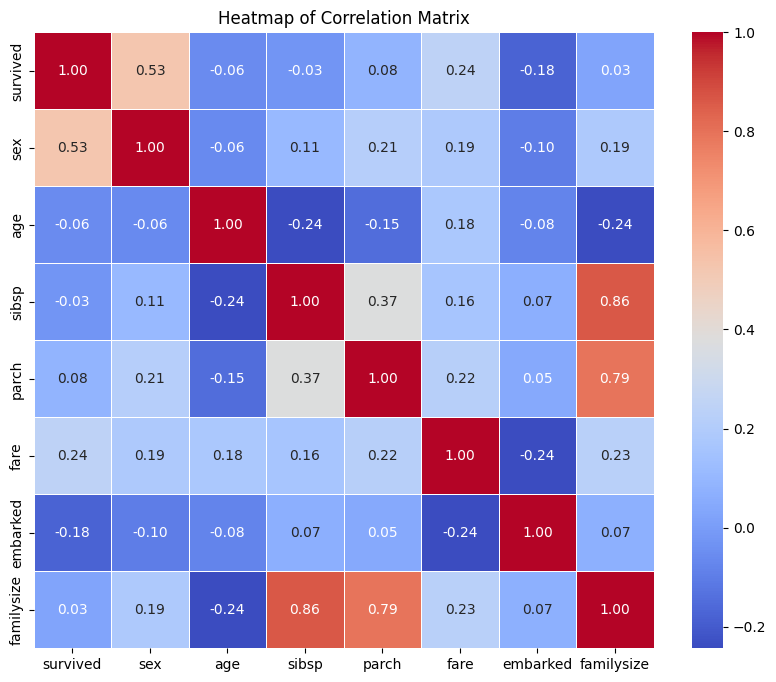

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Heatmap of Correlation Matrix")
plt.show()


Strong correlation: A positive correlation with females and a negative correlation with men. This shows us that females had a higher survival rate in comparison with men. This directly correlates with the historical “women and children first”, phrase that was used.

 Negative correlation: passengers in first class had a higher survival rate than those in 3rd. Well of passengers had better access to survival equipment such as lifeboats

Fare: Positive correlation. Higher fares had a positive correlation with survival. Those who paid higher fares were more than likely in first class meaning better access to rescue equipment.

Age: Likely weak correlation to survived. While age sometimes mattered for certain groups eg children. The overall correlation was weak through the dataset

Family size: Weak correlation. Travelling with family could increase survival rates e.g. help from family members but overall was weak.


In [ ]:
titanic5.to_csv('titanic5.csv')

In [ ]:
%%R
titanic5 <-read.csv("/content/titanic5.csv")
glimpse(titanic5)

Rows: 1,309
Columns: 12
$ X          <int> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 1…
$ pclass     <chr> "1st", "1st", "1st", "1st", "1st", "1st", "1st", "1st", "1s…
$ survived   <int> 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,…
$ name       <chr> "Allen, Miss. Elisabeth Walton", "Allison, Master. Hudson T…
$ sex        <int> 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,…
$ age        <dbl> 29.0000, 0.9167, 2.0000, 30.0000, 25.0000, 48.0000, 63.0000…
$ sibsp      <int> 0, 1, 1, 1, 1, 0, 1, 0, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,…
$ parch      <int> 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,…
$ fare       <dbl> 211.3375, 151.5500, 151.5500, 151.5500, 151.5500, 26.5500, …
$ embarked   <dbl> 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0,…
$ home.dest  <chr> "St Louis, MO", "Montreal, PQ / Chesterville, ON", "Montrea…
$ familysize <int> 1, 4, 4, 4, 4, 1, 2, 1, 3, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1,…


# Tree Models

Tree models are a class of supervised machine learning algorithms that split the dataset into subsets based on the value of input features. For the Titanic3 dataset, classification tree models can help identify relationships between predictor variables (e.g., age, sex, class) and the target variable (`Survived`).


Tree models, such as decision trees, are powerful tools for analyzing data and extracting insights from complex relationships. In the Titanic3 dataset, tree models can uncover critical predictors and interactions affecting survival rates.

**Which Predictor Variables Should Be Included in Models A Priori?**
Predictor Description: Based on the EDA and correlation matrix, we can observe some predictors positively correlate and some negatively correlate with the target variable (Survived), therefore, the following predictors are included.

Sex: A Strong CorrelationVariable Female passengers were much more likely to survive.

Pclass: This is socio-economic status captured by passenger class (1st = upper, 2nd = middle, 3rd = lower).

Fare: Close to Pclass, higher fares equal wealthier passengers with higher chances of survival.

Age: Although weakly correlated to Survived, younger passenger — particularly children — were prioritized for rescue.
SibSp and Parch: The presence of family connections on the Titanic could affect survival, so combining these into a FamilySize variable may more accurately capture their impact.

Embarkation port: The embarkation port could indirectly correspond to socioeconomic status and access to lifeboats.

By including them, it ensures that the model encompasses a significant number of factors determining survival.

 **Are There Any Interactions That Should Be Considered for Inclusion in the Model?**
Tree models inherently capture interactions between variables, making them suitable for identifying how features jointly influence survival. Based on EDA, the following interactions are of interest:

Sex and Pclass:

This was no doubt one of the highest survival rates for women on the ship, given the treatment of women in 1st class during the disaster.

This allows us to show how survival probabilities depend simultaneously on socio-economic status and gender.

Pclass and Age:

Younger passengers in 1st and 2nd class might have higher survival rates compared to those in 3rd class.
Including this interaction helps capture nuances in survival chances across age groups and socio-economic strata.
Family Size:

Larger families may face challenges in evacuating together, potentially lowering survival chances for some members.
This variable can reveal how family dynamics influenced survival outcomes.
Embarked and Fare:

Passengers who embarked at different ports paid varying fares, which could indicate differences in cabin location and survival probabilities.

**How Tree Models Help Understand These Relationships**

Tree models rank predictors based on their contribution to reducing uncertainty in the target variable (Survived).
For example, features like Sex and Pclass might rank highest, confirming their importance.
Capturing Non-Linear Relationships:

Unlike linear models, decision trees handle non-linear interactions and complex patterns, such as the combined effects of Sex, Pclass, and Fare.
Visualization:

The tree structure clearly illustrates decision paths, showing how variables like Sex and Age influence survival probabilities at each split.
Interactions:

Tree models naturally explore and highlight interactions between variables (e.g., Pclass and Sex), revealing joint effects without manual feature engineering.

Variables like Sex and Pclass strongly correlate with survival, emphasizing their inclusion in the model.
Heat map reveal weak to moderate correlations among predictors, suggesting minimal risk of multicollinearity.
Feature importance plots and decision tree visualizations highlight how specific splits (e.g., Sex == female or Pclass <= 2) impact survival predictions.
Interaction effects, such as how younger passengers in 1st class have higher survival rates, are clearly captured in the tree structure.


# Tree Models
Tree models are a class of supervised machine learning algorithms that split the dataset into subsets based on the value of input features. For the Titanic3 dataset, classification tree models can help identify relationships between predictor variables (e.g., age, sex, class) and the target variable (Survived).

Tree models, such as decision trees, are powerful tools for analyzing data and extracting insights from complex relationships. In the Titanic3 dataset, tree models can uncover critical predictors and interactions affecting survival rates.
Which Predictor Variables Should Be Included in Models A Priori? Predictor Description: Based on the EDA and correlation matrix, we can see some predictors positively correlate and some negatively correlate with the target variable (Survived), therefore, the following predictors are included.

Sex: Strong Correlation Variable Female passengers were much more likely to survive.

Plass: This is socio-economic status shown by passenger class (1st, 2nd, 3rd ).

Fare: Close to Pclass, higher fares equate to wealthier passengers with a higher rate of survival.

Age: Although weakly correlated to Survived, younger passengers — in paticular children — were put first for rescue.

 SibSp and Parch: family members on the Titanic could affect survival, so combining these into a FamilySize variable may more accurately capture their impact.

Embarkation port: The embarkation port could indirectly relate to socioeconomic status and access to lifeboats.

Are There Any Interactions That Should Be Considered for Inclusion in the Model? Tree models capture interactions between variables, making them very good for identifying how features influence survival. After review of the EDA, the following interactions are of interest:

Sex and Pclass:

This was no question, one of the highest survival rates for women on the ship was women in first class. They were wealthy and had preferential acces to lifeboats

This allows us to show how survival probabilities depend simultaneously on socio-economic status and gender.

Pclass and Age:

Younger passengers in 1st and 2nd class could have higher survival rates compared to those in 3rd class. Including this interaction helps capture nuances in survival chances across age groups and socio-economic situations.

 Family Size:

Larger families may face challenges in evacuating together, this could decrease survival status of certain members of the family. This variable can reveal how family dynamics influenced survival outcomes.  

Embarked and Fare:

Passengers who embarked at different ports paid different fares, which could show differences in cabin position affects survival probabilities.

How Tree Models Help Understand These Relationships

Tree models rank predictors based on their contribution to decreasing uncertainty in the target variable (Survived). For example, features like Sex and Pclass may rank highest, emphasizing their importance.  

Capturing Non-Linear Relationships:

Unlike linear models, decision trees deal with non-linear interactions and in-depth patterns, such as the combined effects of Sex, Pclass, and Fare.  

Visualization:

The tree structure shows decision paths, showing how variables like Sex and Age influence survival probabilities at each split.  

Interactions:

Tree models naturally explore and highlight interactions between variables (e.g., Pclass and Sex), revealing joint effects without manual feature engineering.

Variables like Sex and Pclass strongly correlate with survival, emphasizing their inclusion in the model. Heat maps reveal weak to moderate correlations among predictors, suggesting minimal risk of multicollinearity. Feature importance plots and decision tree visualizations highlight how specific splits (e.g., Sex == female or Pclass <= 2) impact survival predictions. Interaction effects, such as how younger passengers in 1st class have higher survival rates, are clearly captured in the tree structure.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Data preprocessing
# Handle missing values
titanic5['age'].fillna(titanic5['age'].median(), inplace=True)
titanic5['embarked'].fillna(titanic5['embarked'].mode()[0], inplace=True)



<ipython-input-77-315710381e07>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic5['age'].fillna(titanic5['age'].median(), inplace=True)
<ipython-input-77-315710381e07>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [ ]:
X = titanic5.drop(['survived', 'name','pclass','home.dest'], axis=1)  # Dropping non-predictive columns
y = titanic5['survived']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Build the decision tree classifier
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
# Evaluate the model
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7748091603053435
Confusion Matrix:
 [[125  19]
 [ 40  78]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.87      0.81       144
           1       0.80      0.66      0.73       118

    accuracy                           0.77       262
   macro avg       0.78      0.76      0.77       262
weighted avg       0.78      0.77      0.77       262



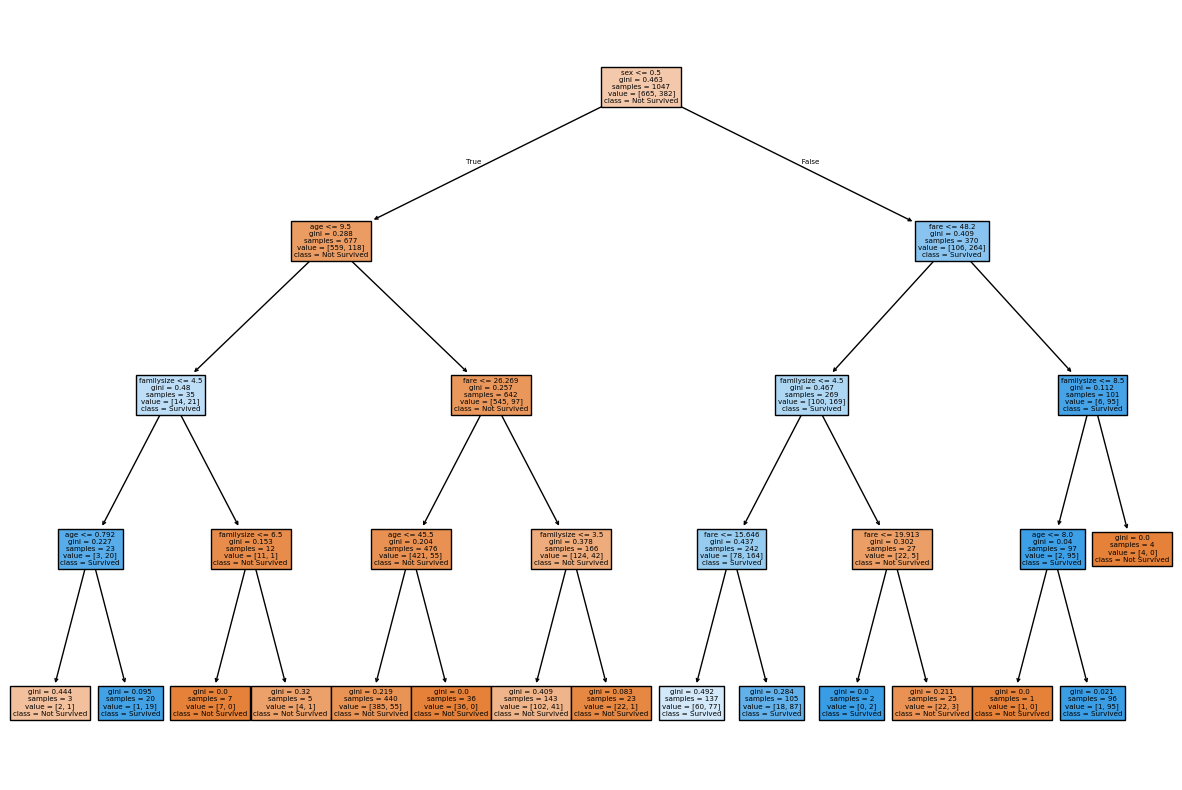

In [ ]:
# Visualize the decision tree
plt.figure(figsize=(15, 10))
plot_tree(clf, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

# Results

In this section, the findings from the exploratory data analysis (EDA) and tree model applications are summarized to provide clear insights into survival determinants in the Titanic dataset. The emphasis is on interpreting the results and ensuring they are understandable to non-technical readers.



From the exploratory data analysis, several key patterns and relationships were identified:

Sex: Gender played a key role in survival. Women had a significantly higher survival rates than men, as shown by a strong positive correlation between female and male.

 Survived. Pclass: Socio-economic status was also a big factor in survival outcomes. Passengers in 1st class had a higher chance of survival than those in 2nd or 3rd class.

 Fare: Higher ticket prices often related to those with 1st class tickets. This positively correlated with survival rates.  

Age: While age had a weak overall correlation with survival, children tended to have better survival rates than others

. Family Size: A moderate relationship was observed, with larger families faced challenges in evacuation.  

Embarked: Passengers embarking from Cherbourg showed slightly higher survival rates, this could be put down to socio economic factors. Visualizations such as heat maps, bar plots, and box plots solidified these findings, providing a clear picture of survival patterns across different groups.

Tree models, such as decision trees, were used to better to understand and predict survival outcomes based on the identified features. The following observations summarize the results:

Sex was the most significant predictor, consistently appearing as the first split in the decision tree. Female passengers had higher survival probabilities. Pclass was the second most influential variable, with 1st class passengers showing the best survival chances. Fare ranked high in importance, reflecting wealthier passengers' greater likelihood of survival. Other variables, such as Age, Family Size, and Embarked, contributed to the model but were less impactful compared to Sex and Pclass. Tree Structure Decision tree visualization highlighted: First Split: The model typically split data based on Sex (e.g., Sex == female). Subsequent Splits: Variables such as Pclass and Fare further divided the dataset, refining survival predictions. Example: Women in 1st class who paid higher fares had the highest predicted survival rates. Interactions Interactions like Sex × Pclass (e.g., women in lower classes had lower survival rates than women in 1st class) were effectively captured by the tree model. Age × Pclass interaction revealed that younger passengers in 1st class had better outcomes than older passengers in 3rd class.









**Key Findings**
The tree models revealed survival was most influenced by Sex, Pclass, and Fare. These factors highlight socio-economic disparities and gender-based prioritization during the Titanic disaster.
Interactions such as Sex × Pclass and Age × Pclass provided deeper insights into how demographic and economic factors combined to influence survival.
Family size and port of embarkation had moderate but noticeable effects on outcomes.


https://chatgpt.com/share/67912f57-4d58-8007-b353-359c6fb78d35

https://chatgpt.com/share/67912f87-bcc0-8007-8997-27227630c4fd